# Test 01: Generador de Señal Pupilar

Pruebas del generador avanzado de señal pupilar utilizando la clase `PupilSignalGenerator`.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from lib.generadores.model import PupilSignalGenerator
import numpy as np

## Caso 1: Sujeto Control (No Patológico)

In [2]:
# Generar señal control (nivel de afectación bajo)
generador = PupilSignalGenerator(fs=60.0, seed=42, nivel_afectacion=0.1)
t, señal_control = generador.generar(duracion=30.0)

print(f"Muestras generadas: {len(señal_control)}")
print(f"Duración: {t[-1]:.2f} s")
print(f"Diámetro medio: {np.mean(señal_control):.3f} mm")
print(f"Desviación estándar: {np.std(señal_control):.3f} mm")

Muestras generadas: 1800
Duración: 30.00 s
Diámetro medio: 0.586 mm
Desviación estándar: 0.349 mm


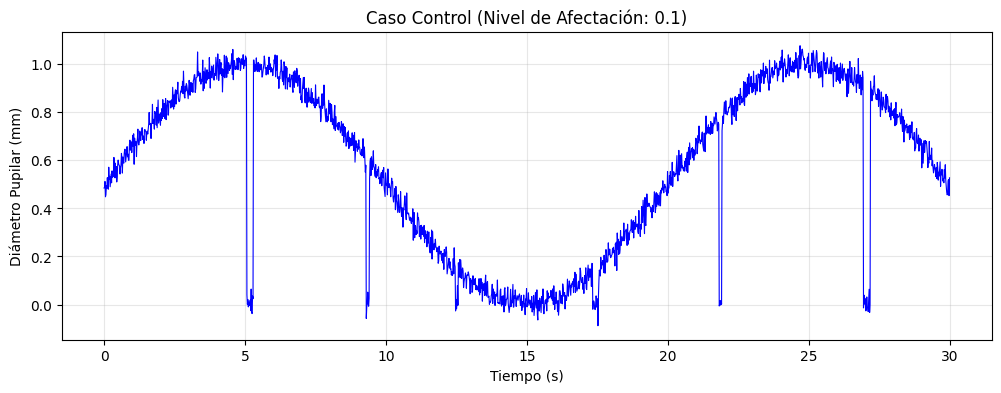

In [3]:
# Visualizar señal control
generador.view(t, señal_control, titulo="Caso Control (Nivel de Afectación: 0.1)")

## Caso 2: Sujeto Patológico (Migraña Vestibular)

In [4]:
# Generar señal patológica (nivel de afectación alto)
generador_pat = PupilSignalGenerator(fs=60.0, seed=43, nivel_afectacion=0.9)
t, señal_patologica = generador_pat.generar(duracion=30.0)

print(f"Muestras generadas: {len(señal_patologica)}")
print(f"Duración: {t[-1]:.2f} s")
print(f"Diámetro medio: {np.mean(señal_patologica):.3f} mm")
print(f"Desviación estándar: {np.std(señal_patologica):.3f} mm")

Muestras generadas: 1800
Duración: 30.00 s
Diámetro medio: 0.583 mm
Desviación estándar: 0.353 mm


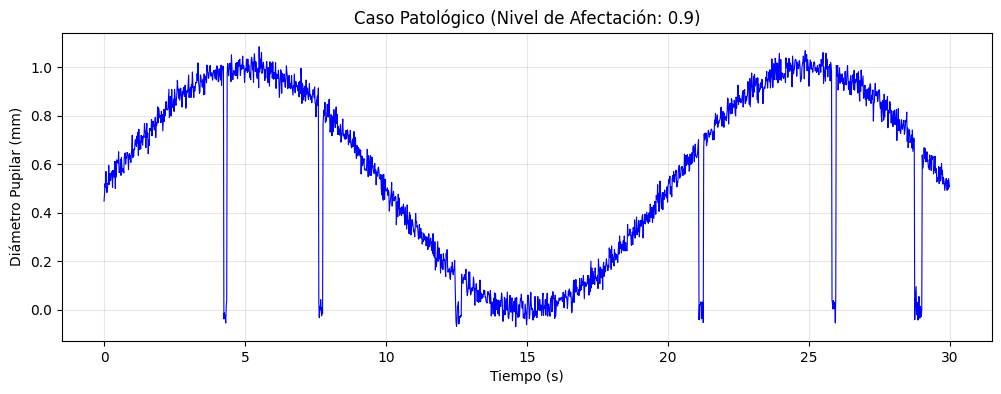

In [5]:
# Visualizar señal patológica
generador_pat.view(t, señal_patologica, titulo="Caso Patológico (Nivel de Afectación: 0.9)")

## Caso 3: Comparación Control vs Patológico

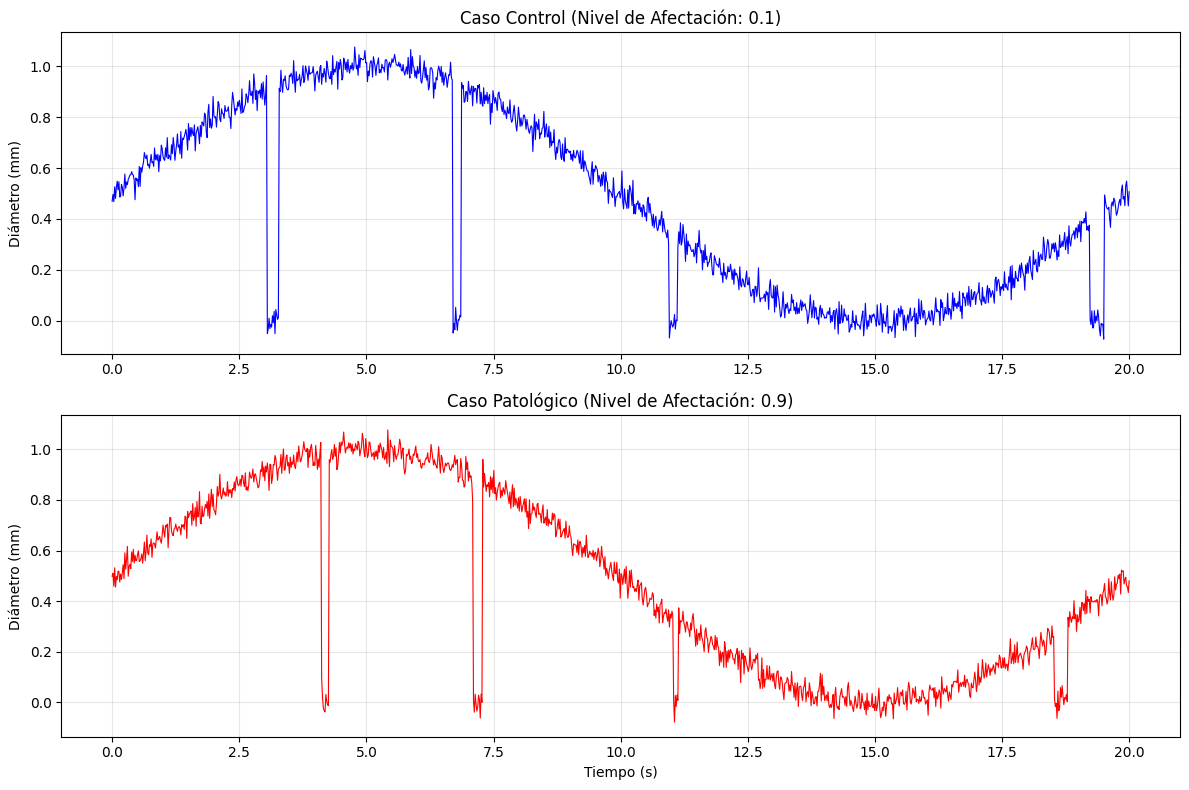

In [6]:
import matplotlib.pyplot as plt

# Generar múltiples señales para comparación
generador_comp = PupilSignalGenerator(fs=60.0, seed=44)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Control (nivel bajo)
gen_control = PupilSignalGenerator(fs=60.0, seed=44, nivel_afectacion=0.1)
t, señal_control = gen_control.generar(duracion=20.0)
axes[0].plot(t, señal_control, color='blue', linewidth=0.8)
axes[0].set_title('Caso Control (Nivel de Afectación: 0.1)')
axes[0].set_ylabel('Diámetro (mm)')
axes[0].grid(True, alpha=0.3)

# Patológico (nivel alto)
gen_pat = PupilSignalGenerator(fs=60.0, seed=45, nivel_afectacion=0.9)
t, señal_patologica = gen_pat.generar(duracion=20.0)
axes[1].plot(t, señal_patologica, color='red', linewidth=0.8)
axes[1].set_title('Caso Patológico (Nivel de Afectación: 0.9)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Diámetro (mm)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resumen de Estadísticas

## Caso 4: Prueba de nivel_afectacion

TypeError: PupilSignalGenerator.generar() got an unexpected keyword argument 'es_patologico'

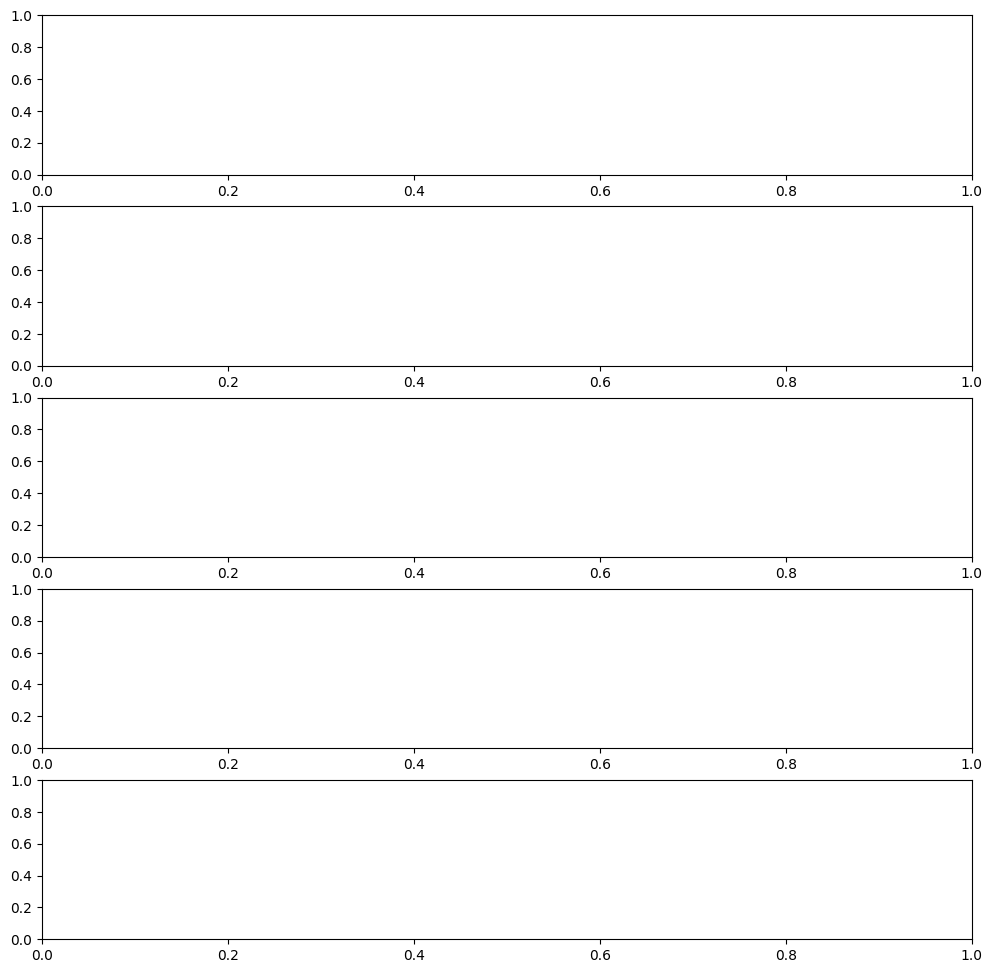

In [7]:
# Probar diferentes niveles de afectación
niveles = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(len(niveles), 1, figsize=(12, 12))

for i, nivel in enumerate(niveles):
    gen = PupilSignalGenerator(fs=60.0, seed=50+i, nivel_afectacion=nivel)
    t, señal = gen.generar(es_patologico=True, duracion=20.0)
    
    axes[i].plot(t, señal, color='red', linewidth=0.8)
    axes[i].set_title(f'Nivel de Afectación: {nivel:.2f}')
    axes[i].set_ylabel('Diámetro (mm)')
    axes[i].grid(True, alpha=0.3)
    
    if i == len(niveles) - 1:
        axes[i].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

In [ ]:
# Comparar estadísticas entre múltiples generaciones
n_iteraciones = 10

stats_control = []
stats_patologico = []

for i in range(n_iteraciones):
    gen_control = PupilSignalGenerator(fs=60.0, nivel_afectacion=0.1)
    t, señal = gen_control.generar(duracion=30.0)
    stats_control.append({
        'media': np.mean(señal),
        'std': np.std(señal),
        'min': np.min(señal),
        'max': np.max(señal)
    })
    
    gen_pat = PupilSignalGenerator(fs=60.0, nivel_afectacion=0.9)
    t, señal = gen_pat.generar(duracion=30.0)
    stats_patologico.append({
        'media': np.mean(señal),
        'std': np.std(señal),
        'min': np.min(señal),
        'max': np.max(señal)
    })

print("=== Estadísticas Control (Nivel 0.1) ===")
print(f"Media promedio: {np.mean([s['media'] for s in stats_control]):.3f} ± {np.std([s['media'] for s in stats_control]):.3f}")
print(f"Std promedio: {np.mean([s['std'] for s in stats_control]):.3f} ± {np.std([s['std'] for s in stats_control]):.3f}")

print("\n=== Estadísticas Patológico (Nivel 0.9) ===")
print(f"Media promedio: {np.mean([s['media'] for s in stats_patologico]):.3f} ± {np.std([s['media'] for s in stats_patologico]):.3f}")
print(f"Std promedio: {np.mean([s['std'] for s in stats_patologico]):.3f} ± {np.std([s['std'] for s in stats_patologico]):.3f}")